Exploratory Data Analysis for Cross-Platform Cyberbullying Detection

Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud

sns.set(style="whitegrid")

Load Datasets

In [2]:
# Detect project root
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
if not os.path.exists(os.path.join(project_root, "data")):
    project_root = current_dir

# Paths
dataset1_path = os.path.join(project_root, "data", "raw", "cross_platform_dataset.csv")
dataset2_path = os.path.join(project_root, "data", "raw", "kaggle_dataset.csv")
dataset3_path = os.path.join(project_root, "data", "raw", "twitter.csv")

# Load datasets
df1 = pd.read_csv(dataset1_path)
df2 = pd.read_csv(dataset2_path)
df3 = pd.read_csv(dataset3_path)

print("Datasets loaded successfully ✅")

Datasets loaded successfully ✅


Harmonize Columns & Labels

In [3]:
# Dataset 1
# Rename columns for consistency
df1.rename(columns={"Text_Content": "Text_Content", "Platform": "Platform", "Target": "Label"}, inplace=True)
# Map to binary labels
df1["Label"] = df1["Label"].apply(lambda x: "Cyberbullying" if x=="Cyberbullying" else "not_cyberbullying")

# Dataset 2 (Kaggle Twitter)
df2.rename(columns={"tweet_text": "Text_Content", "cyberbullying_type": "Label"}, inplace=True)
# Add Platform column
df2["Platform"] = "Twitter"
df2["Label"] = df2["Label"].apply(lambda x: "not_cyberbullying" if x=="not_cyberbullying" else "Cyberbullying")

# Dataset 3 (Twitter API Fetched)
df3.rename(columns={"text":"Text_Content", "label":"label", "platform":"Platform"}, inplace=True)
df3["Label"] = df3["label"].apply(lambda x: "Cyberbullying" if x==1 else "not_cyberbullying")

# Text Length Column
for d in [df1, df2, df3]:
    d["text_length"] = d["Text_Content"].apply(len)

Label Distribution Bar Plots

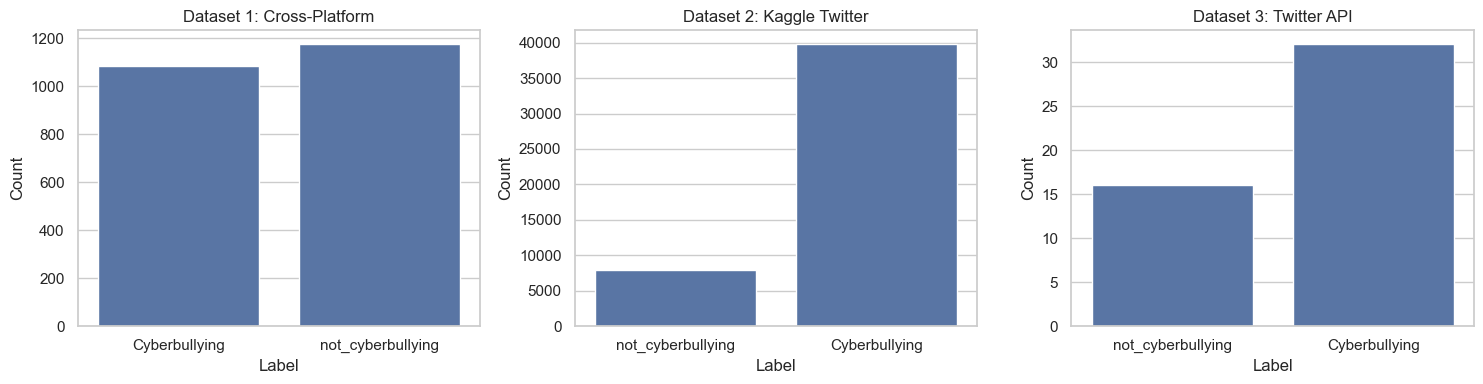

In [4]:
plt.figure(figsize=(15,4))
datasets = [df1, df2, df3]
titles = ["Dataset 1: Cross-Platform", "Dataset 2: Kaggle Twitter", "Dataset 3: Twitter API"]

for i, d in enumerate(datasets):
    plt.subplot(1,3,i+1)
    sns.countplot(x="Label", data=d)
    plt.title(titles[i])
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

Text Length Boxplots & Histograms

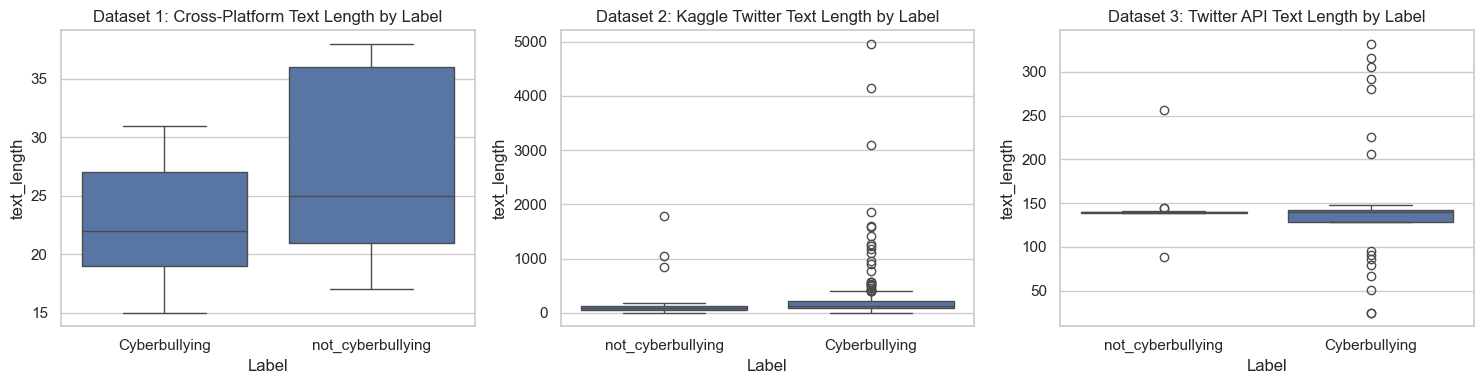

In [5]:
# Boxplots
plt.figure(figsize=(15,4))
for i, d in enumerate(datasets):
    plt.subplot(1,3,i+1)
    sns.boxplot(x="Label", y="text_length", data=d)
    plt.title(f"{titles[i]} Text Length by Label")
plt.tight_layout()
plt.show()

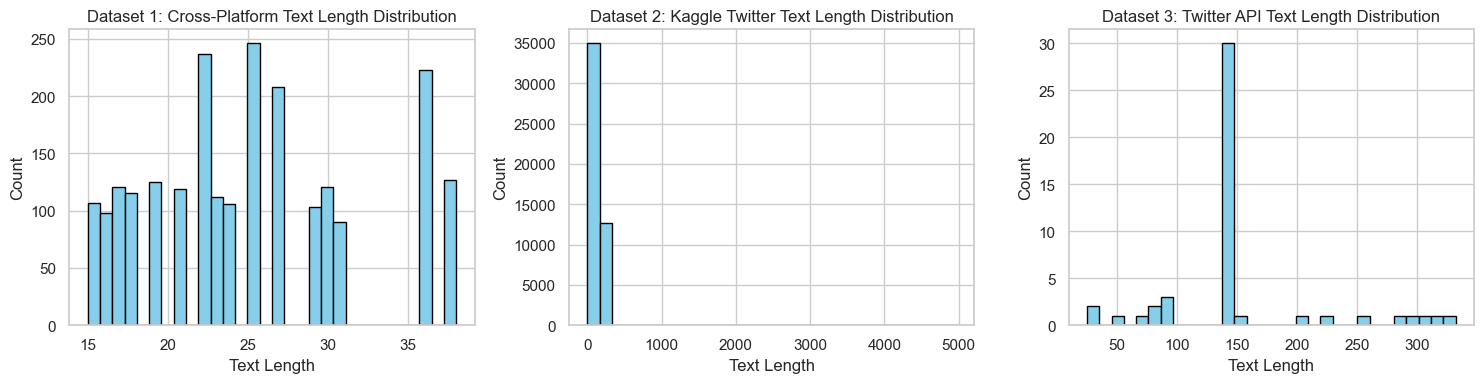

In [6]:
# Histograms
plt.figure(figsize=(15,4))
for i, d in enumerate(datasets):
    plt.subplot(1,3,i+1)
    plt.hist(d["text_length"], bins=30, color="skyblue", edgecolor="black")
    plt.title(f"{titles[i]} Text Length Distribution")
    plt.xlabel("Text Length")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()


Platform-wise Distribution (for Dataset 1)

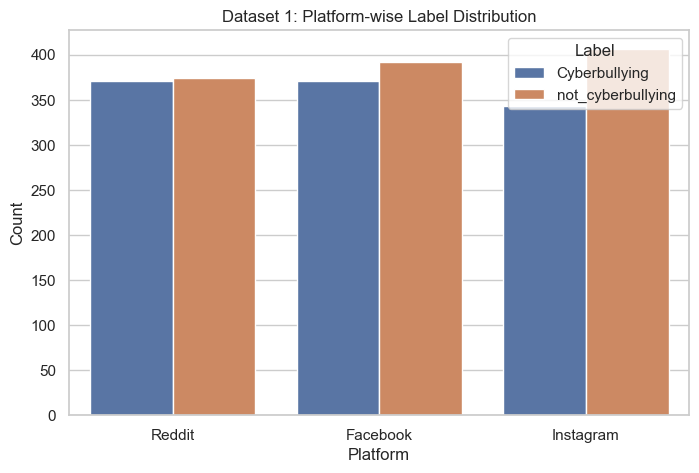

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x="Platform", hue="Label", data=df1)
plt.title("Dataset 1: Platform-wise Label Distribution")
plt.ylabel("Count")
plt.show()

Top Words per Class (Dataset 1 example)

In [8]:
def top_words(df, label, n=20):
    text = " ".join(df[df["Label"]==label]["Text_Content"].tolist()).lower()
    words = [w for w in text.split() if w not in ENGLISH_STOP_WORDS]
    return Counter(words).most_common(n)

print("Top words in Cyberbullying posts (Dataset 1):")
print(top_words(df1, "Cyberbullying"))

print("\nTop words in not_cyberbullying posts (Dataset 1):")
print(top_words(df1, "not_cyberbullying"))

Top words in Cyberbullying posts (Dataset 1):
[('stop', 246), ("you're", 204), ('pathetic', 125), ('just', 123), ('disappear', 123), ('dumb,', 121), ('posting!', 121), ('here?', 114), ('likes', 112), ('loser', 107), ('annoying', 106), ('worthless', 98), ('cares', 90), ('opinion', 90), ('hate', 89)]

Top words in not_cyberbullying posts (Dataset 1):
[('congratulations', 128), ('achievement.', 128), ('looking', 127), ('forward', 127), ('event', 127), ('tomorrow.', 127), ('appreciate', 126), ('effort.', 126), ('like', 121), ('idea.', 121), ('totally', 120), ('agree', 120), ('you.', 120), ('great', 119), ('work', 119), ('project!', 119), ('helpful.', 119), ('good', 115), ('job', 115), ('everyone!', 115)]


Word Cloud

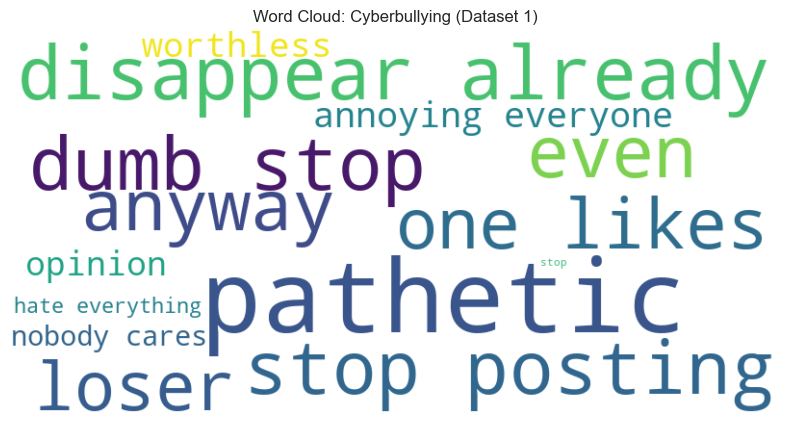

In [9]:
cyber_text = " ".join(df1[df1["Label"]=="Cyberbullying"]["Text_Content"].tolist()).lower()
wc = WordCloud(width=800, height=400, background_color='white').generate(cyber_text)

plt.figure(figsize=(15,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud: Cyberbullying (Dataset 1)")
plt.show()

Check for Duplicates

In [10]:
for i, d in enumerate(datasets):
    print(f"{titles[i]} duplicates:", d.duplicated().sum())

Dataset 1: Cross-Platform duplicates: 0
Dataset 2: Kaggle Twitter duplicates: 176
Dataset 3: Twitter API duplicates: 0


Summary Table

In [11]:
summary = pd.DataFrame({
    "Dataset": ["Dataset 1", "Dataset 2", "Dataset 3"],
    "Rows": [len(df1), len(df2), len(df3)],
    "Columns": [df1.shape[1], df2.shape[1], df3.shape[1]],
    "Cyberbullying": [df1["Label"].value_counts().get("Cyberbullying",0),
                       df2["Label"].value_counts().get("Cyberbullying",0),
                       df3["Label"].value_counts().get("Cyberbullying",0)],
    "not_cyberbullying": [df1["Label"].value_counts().get("not_cyberbullying",0),
                           df2["Label"].value_counts().get("not_cyberbullying",0),
                           df3["Label"].value_counts().get("not_cyberbullying",0)],
    "Avg Text Length (Cyberbullying)": [df1[df1["Label"]=="Cyberbullying"]["text_length"].mean(),
                                        df2[df2["Label"]=="Cyberbullying"]["text_length"].mean(),
                                        df3[df3["Label"]=="Cyberbullying"]["text_length"].mean()],
    "Avg Text Length (not_cyberbullying)": [df1[df1["Label"]=="not_cyberbullying"]["text_length"].mean(),
                                            df2[df2["Label"]=="not_cyberbullying"]["text_length"].mean(),
                                            df3[df3["Label"]=="not_cyberbullying"]["text_length"].mean()]
})

summary

,Dataset,Rows,Columns,Cyberbullying,not_cyberbullying,Avg Text Length (Cyberbullying),Avg Text Length (not_cyberbullying)
0,Dataset 1,2258,5,1085,1173,22.769585,27.135550
1,Dataset 2,47692,4,39747,7945,146.830553,83.102077
2,Dataset 3,48,6,32,16,151.875000,144.312500
